# Práctica 1: Limpieza y transformación de datos en Online Retail

**Alumno:** Eduardo Alonso Sánchez  
**Boleta:** 2023630155  
**Grupo:** 7CV4  
**Unidad de aprendizaje:** C703 - Big Data | Big Data  
**Docente:** Tania Rodríguez Sarabia  
**Periodo escolar:** 20271

La boleta termina en **0155**. La consigna pide convertir los últimos cuatro dígitos a entero, por lo que `digitos_boleta = 155` se usa para módulos y paridad. Se conserva `identificador = "0155"` para búsquedas, etiquetas y nombres de archivo. Así se evita perder el cero inicial en las salidas legibles.

Fuentes técnicas: [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online%2Bretail), [repositorio de Databricks indicado en la consigna](https://github.com/databricks/Spark-The-Definitive-Guide/tree/master/data/retail-data/all), [duplicados en pandas](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html), [conversión de fechas](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) y [recorte con `clip`](https://pandas.pydata.org/docs/reference/api/pandas.Series.clip.html).

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import hashlib
import json
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")

nombre = "Eduardo Alonso Sánchez"
boleta_completa = "2023630155"
identificador = boleta_completa[-4:]
digitos_boleta = int(identificador)

ROOT = Path.cwd()
RAW_DIR = ROOT / "datos" / "raw"
PROCESSED_DIR = ROOT / "datos" / "processed"
ASSETS_DIR = ROOT / "assets"
for carpeta in (RAW_DIR, PROCESSED_DIR, ASSETS_DIR):
    carpeta.mkdir(parents=True, exist_ok=True)

DATA_URL = "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv"
RAW_PATH = RAW_DIR / "online-retail-dataset.csv"
if not RAW_PATH.exists():
    print("Descargando dataset indicado por la consigna...")
    urlretrieve(DATA_URL, RAW_PATH)

print(f"Alumno: {nombre}")
print(f"Boleta: {boleta_completa}")
print(f"Dígitos únicos (entero): {digitos_boleta}")
print(f"Identificador escrito: {identificador}")
print(f"Fecha de ejecución: {pd.Timestamp.now()}")
print(f"Python: {platform.python_version()} | pandas: {pd.__version__} | numpy: {np.__version__}")

Alumno: Eduardo Alonso Sánchez
Boleta: 2023630155
Dígitos únicos (entero): 155
Identificador escrito: 0155
Fecha de ejecución: 2026-09-06 17:48:15.451783
Python: 3.12.14 | pandas: 2.2.3 | numpy: 2.3.5


## Punto 2. Carga y exploración inicial

In [2]:
sha256_raw = hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()
df = pd.read_csv(
    RAW_PATH,
    encoding="utf-8",
    dtype={"InvoiceNo": "string", "StockCode": "string"},
)
columnas_fuente = df.columns.tolist()
filas_originales = len(df)

print(f"Archivo: {RAW_PATH}")
print(f"SHA-256: {sha256_raw}")
print(f"Dimensión original: {df.shape}")
print("\nPrimeras 10 filas:")
display(df.head(10))
print("\nInformación del dataframe:")
df.info()
print("\nEstadísticas descriptivas:")
display(df.describe(include="all").transpose())

Archivo: /home/eddndev/Documents/ESCOM/BD/01-limpieza-datos-retail/datos/raw/online-retail-dataset.csv
SHA-256: a2f79bbdd4463df6db8a3f5a50b9c980ae8f645a370bf5e2c0d6097f9e817b05
Dimensión original: (541909, 8)

Primeras 10 filas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom



Información del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  string 
 1   StockCode    541909 non-null  string 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(3), string(2)
memory usage: 33.1+ MB

Estadísticas descriptivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
N = digitos_boleta % 100 + 100
df_visualizacion = df.head(N).copy()
print(f"N = {digitos_boleta} % 100 + 100 = {N}")
print("df_visualizacion se limita a la presentación; la limpieza continúa sobre df completo.")
display(df_visualizacion)

N = 155 % 100 + 100 = 155
df_visualizacion se limita a la presentación; la limpieza continúa sobre df completo.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


## Punto 3. Limpieza de valores nulos

In [4]:
nulos_conteo_inicial = df.isna().sum()
nulos_porcentaje_inicial = (nulos_conteo_inicial / len(df) * 100).round(6)
reporte_nulos = pd.DataFrame({"Nulos": nulos_conteo_inicial, "Porcentaje": nulos_porcentaje_inicial})
display(reporte_nulos)

nulos_customer = int(df["CustomerID"].isna().sum())
nulos_description = int(df["Description"].isna().sum())
nulos_invoice = int(df["InvoiceNo"].isna().sum())

# 155 es impar: la estrategia asignada es imputar CustomerID con 10000 + 155 = 10155.
customer_id_imputado = 10000 + digitos_boleta
df["CustomerID"] = df["CustomerID"].fillna(customer_id_imputado).astype("Int64")
df["Description"] = df["Description"].fillna(f"NO_DESCRIPCION_{identificador}")
df = df.dropna(subset=["InvoiceNo"]).copy()

print(f"CustomerID imputados con {customer_id_imputado}: {nulos_customer:,}")
print(f"Description imputadas con NO_DESCRIPCION_{identificador}: {nulos_description:,}")
print(f"Filas eliminadas por InvoiceNo nulo: {nulos_invoice:,}")
print(f"Filas restantes: {len(df):,}")

,Nulos,Porcentaje
InvoiceNo,0,0.000000
StockCode,0,0.000000
Description,1454,0.268311
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
CustomerID,135080,24.926694
Country,0,0.000000


CustomerID imputados con 10155: 135,080
Description imputadas con NO_DESCRIPCION_0155: 1,454
Filas eliminadas por InvoiceNo nulo: 0
Filas restantes: 541,909


## Punto 4. Duplicados y redundancia

In [5]:
# La columna de auditoría se agrega sin alterar la definición de duplicado exacto.
df["Fila_Original"] = df.index.astype("int64") + 1  # posición ordinal del registro en el CSV
duplicados_exactos = int(df.duplicated(subset=columnas_fuente, keep="first").sum())
filas_antes_duplicados = len(df)
clave_negocio = ["InvoiceNo", "StockCode", "CustomerID"]

# 155 es impar: se conserva la primera fila por la clave crítica indicada.
df = df.drop_duplicates(subset=clave_negocio, keep="first").copy()
filas_despues_duplicados = len(df)
eliminadas_redundancia = filas_antes_duplicados - filas_despues_duplicados
porcentaje_redundancia = eliminadas_redundancia / filas_antes_duplicados * 100

print(f"Duplicados exactos detectados: {duplicados_exactos:,}")
print(f"Antes: {filas_antes_duplicados:,} | Después: {filas_despues_duplicados:,}")
print(f"Eliminados por clave {clave_negocio}: {eliminadas_redundancia:,} ({porcentaje_redundancia:.6f}%)")

Duplicados exactos detectados: 5,268
Antes: 541,909 | Después: 531,225
Eliminados por clave ['InvoiceNo', 'StockCode', 'CustomerID']: 10,684 (1.971549%)


## Punto 5. Validación y corrección de tipos

In [6]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%Y %H:%M", errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")

# Se preservan los valores de origen antes del capping para auditar devoluciones y ventas.
df["Quantity_Original"] = df["Quantity"]
df["UnitPrice_Original"] = df["UnitPrice"]
df["Total_Transaccion_Original"] = df["Quantity_Original"] * df["UnitPrice_Original"]
df["Transaccion_Valida"] = (df["Quantity_Original"] > 0) & (df["UnitPrice_Original"] > 0)
df["Es_Cancelacion"] = df["InvoiceNo"].str.upper().str.startswith("C", na=False)

print(df[["InvoiceDate", "Quantity", "UnitPrice", "Transaccion_Valida", "Es_Cancelacion"]].dtypes)
print(f"Fechas no convertibles: {df['InvoiceDate'].isna().sum():,}")
print(f"Transacciones válidas (criterio original): {df['Transaccion_Valida'].sum():,}")
print(f"Registros de cancelación: {df['Es_Cancelacion'].sum():,}")

InvoiceDate           datetime64[ns]
Quantity                       int64
UnitPrice                    float64
Transaccion_Valida              bool
Es_Cancelacion               boolean
dtype: object
Fechas no convertibles: 0
Transacciones válidas (criterio original): 519,582
Registros de cancelación: 9,139


## Punto 6. Detección y manejo de outliers

El IQR se usa para **detectar** valores atípicos. Como el último dígito es 5, la corrección asignada consiste en limitar `Quantity` a los percentiles 5 y 95. Esta transformación es útil para comparar distribuciones, pero altera el significado de cantidades negativas. Por eso se conservan `Quantity_Original`, `Total_Transaccion_Original`, `Transaccion_Valida` y `Es_Cancelacion`.

In [7]:
Q1 = df["Quantity_Original"].quantile(0.25)
Q3 = df["Quantity_Original"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior_iqr = Q1 - 1.5 * IQR
limite_superior_iqr = Q3 + 1.5 * IQR
mascara_outlier_iqr = ~df["Quantity_Original"].between(limite_inferior_iqr, limite_superior_iqr)
outliers_iqr = int(mascara_outlier_iqr.sum())

p5 = df["Quantity_Original"].quantile(0.05)
p95 = df["Quantity_Original"].quantile(0.95)
df["Quantity"] = df["Quantity_Original"].clip(lower=p5, upper=p95)
df["Cantidad_Capeada"] = df["Quantity"].ne(df["Quantity_Original"])
df["Total_Transaccion"] = df["Quantity"] * df["UnitPrice"]
df["Transaccion_Valida_Ajustada"] = (df["Quantity"] > 0) & (df["UnitPrice"] > 0)

filas_capeadas = int(df["Cantidad_Capeada"].sum())
cancelaciones_capeadas = int((df["Cantidad_Capeada"] & df["Es_Cancelacion"]).sum())
negativas_originales = int((df["Quantity_Original"] < 0).sum())
negativas_convertidas_positivas = int(((df["Quantity_Original"] < 0) & (df["Quantity"] > 0)).sum())

print(f"Q1={Q1:g}, Q3={Q3:g}, IQR={IQR:g}; límites IQR=[{limite_inferior_iqr:g}, {limite_superior_iqr:g}]")
print(f"Outliers detectados por IQR: {outliers_iqr:,}")
print(f"Capping p5={p5:g}, p95={p95:g}; filas modificadas: {filas_capeadas:,}")
print(f"Cancelaciones afectadas por capping: {cancelaciones_capeadas:,}")
print(f"Cantidades negativas convertidas a positivas: {negativas_convertidas_positivas:,} de {negativas_originales:,}")

Q1=1, Q3=10, IQR=9; límites IQR=[-12.5, 23.5]
Outliers detectados por IQR: 58,337
Capping p5=1, p95=30; filas modificadas: 36,222
Cancelaciones afectadas por capping: 9,139
Cantidades negativas convertidas a positivas: 10,475 de 10,475


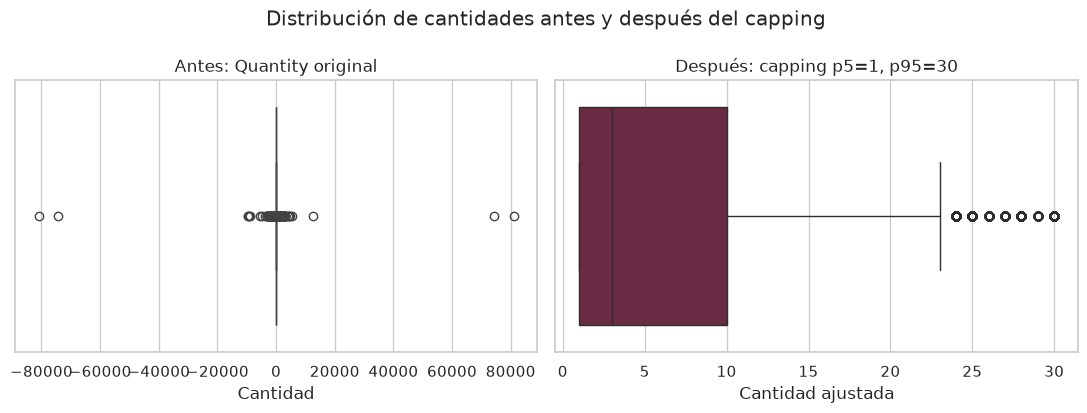

Cinco registros con mayor total original (sin capping):


,InvoiceNo,StockCode,Description,Quantity_Original,UnitPrice_Original,Total_Transaccion_Original,Es_Cancelacion
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,False
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,False
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,False
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,False
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06,False


Cinco registros con mayor total ajustado (dataframe transformado):


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Total_Transaccion,Es_Cancelacion
222681,C556445,M,Manual,1,38970.00,38970.00,True
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,30,649.50,19485.00,False
524602,C580605,AMAZONFEE,AMAZON FEE,1,17836.46,17836.46,True
43702,C540117,AMAZONFEE,AMAZON FEE,1,16888.02,16888.02,True
43703,C540118,AMAZONFEE,AMAZON FEE,1,16453.71,16453.71,True


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.boxplot(x=df["Quantity_Original"], ax=axes[0], color="#2C8BB3", showfliers=True)
axes[0].set_title("Antes: Quantity original")
axes[0].set_xlabel("Cantidad")
sns.boxplot(x=df["Quantity"], ax=axes[1], color="#762042", showfliers=True)
axes[1].set_title(f"Después: capping p5={p5:g}, p95={p95:g}")
axes[1].set_xlabel("Cantidad ajustada")
fig.suptitle("Distribución de cantidades antes y después del capping")
fig.tight_layout()
boxplot_path = ASSETS_DIR / f"boxplot_cantidad_{identificador}.png"
fig.savefig(boxplot_path, dpi=180, bbox_inches="tight")
plt.show()

columnas_top = ["InvoiceNo", "StockCode", "Description", "Quantity_Original", "UnitPrice_Original", "Total_Transaccion_Original", "Es_Cancelacion"]
top5_original = df.nlargest(5, "Total_Transaccion_Original")[columnas_top]
print("Cinco registros con mayor total original (sin capping):")
display(top5_original)

columnas_top_ajustado = ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Total_Transaccion", "Es_Cancelacion"]
top5_ajustado = df.nlargest(5, "Total_Transaccion")[columnas_top_ajustado]
print("Cinco registros con mayor total ajustado (dataframe transformado):")
display(top5_ajustado)

## Punto 7. Normalización y estandarización

In [9]:
df["Country"] = (
    df["Country"].astype("string").str.replace(r"\s+", " ", regex=True).str.strip().str.upper()
)

descripciones_por_producto = df.groupby("StockCode")["Description"].nunique(dropna=True)
productos_descripcion_multiple = int((descripciones_por_producto > 1).sum())

mascara_identificador_stock = df["StockCode"].str.contains(identificador, regex=False, na=False)
filas_stock_identificador = int(mascara_identificador_stock.sum())
productos_stock_identificador = int(df.loc[mascara_identificador_stock, "StockCode"].nunique())

if mascara_identificador_stock.any():
    moda_por_stock = (
        df.loc[mascara_identificador_stock]
        .groupby("StockCode")["Description"]
        .agg(lambda serie: serie.mode().iloc[0] if not serie.mode().empty else serie.iloc[0])
    )
    df.loc[mascara_identificador_stock, "Description"] = (
        df.loc[mascara_identificador_stock, "StockCode"].map(moda_por_stock)
        + f" [UNIFICADO_{identificador}]"
    )

stock_minuscula = df["StockCode"].str.lower()
contiene_gift = stock_minuscula.str.contains("gift", regex=False, na=False)
contiene_letras = df["StockCode"].str.contains(r"[A-Za-z]", regex=True, na=False)
df["Categoria_Producto"] = np.select(
    [contiene_gift, contiene_letras],
    [f"REGALO_{identificador}", "PRODUCTO_ESPECIAL"],
    default="PRODUCTO_NORMAL",
)

print(f"Productos con múltiples descripciones antes de unificar: {productos_descripcion_multiple:,}")
print(f"StockCode que contiene {identificador}: {productos_stock_identificador:,} productos, {filas_stock_identificador:,} filas")
display(df["Categoria_Producto"].value_counts().rename_axis("Categoría").to_frame("Filas"))

Productos con múltiples descripciones antes de unificar: 1,324
StockCode que contiene 0155: 1 productos, 7 filas


,Filas
Categoría,
PRODUCTO_NORMAL,477266
PRODUCTO_ESPECIAL,53925
REGALO_0155,34


## Punto 8. Segmentación de clientes y gasto

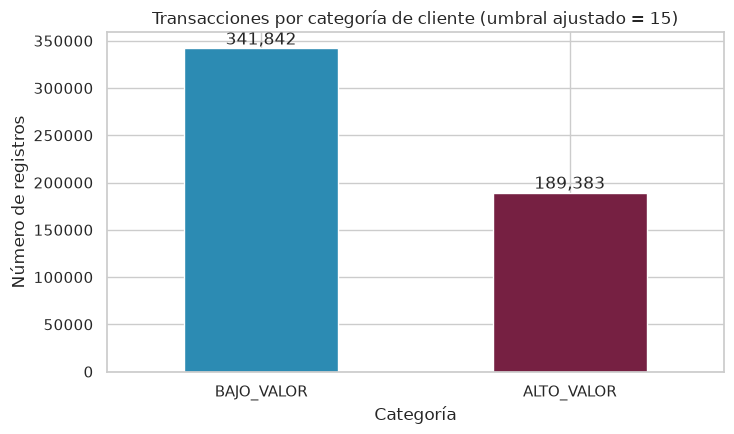

Umbral = 2023630155 % 50 + 10 = 15


,Transacciones
Categoria_Cliente,
BAJO_VALOR,341842
ALTO_VALOR,189383


In [10]:
df["Total_Venta_Original"] = df["Total_Transaccion_Original"]
df["Total_Venta"] = df["Total_Transaccion"]  # total ajustado por la estrategia de capping asignada
umbral = int(boleta_completa) % 50 + 10
df["Categoria_Cliente"] = np.where(df["Total_Venta"] < umbral, "BAJO_VALOR", "ALTO_VALOR")
conteo_categorias_cliente = df["Categoria_Cliente"].value_counts().reindex(["BAJO_VALOR", "ALTO_VALOR"])

ax = conteo_categorias_cliente.plot(kind="bar", figsize=(7.5, 4.5), color=["#2C8BB3", "#762042"])
ax.set_title(f"Transacciones por categoría de cliente (umbral ajustado = {umbral})")
ax.set_xlabel("Categoría")
ax.set_ylabel("Número de registros")
ax.tick_params(axis="x", rotation=0)
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="{:,.0f}")
plt.tight_layout()
categorias_path = ASSETS_DIR / f"categorias_cliente_{identificador}.png"
plt.savefig(categorias_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Umbral = {int(boleta_completa)} % 50 + 10 = {umbral}")
display(conteo_categorias_cliente.to_frame("Transacciones"))

## Punto 9. Exportación y calidad

El CSV conserva las columnas originales y columnas de auditoría. `Total_Venta` refleja la cantidad capeada porque la consigna ordena continuar con el dataframe transformado. `Total_Venta_Original` conserva el importe observado en el archivo. Las cancelaciones siguen identificadas por `Es_Cancelacion`; no se reinterpretan como ventas reales aunque el p5 convierta su cantidad ajustada en positiva.

In [11]:
columnas_busqueda = ["InvoiceNo", "StockCode", "Description", "CustomerID", "Country"]
contiene_identificador = pd.Series(False, index=df.index)
for columna in columnas_busqueda:
    contiene_identificador |= df[columna].astype("string").str.contains(identificador, regex=False, na=False)
filas_con_identificador = int(contiene_identificador.sum())

completitud = float((1 - df.isna().sum().sum() / df.size) * 100)
consistencia_clave = float((1 - df.duplicated(subset=clave_negocio).mean()) * 100)
consistencia_cancelacion = float((df["Es_Cancelacion"] == df["InvoiceNo"].str.upper().str.startswith("C", na=False)).mean() * 100)
consistencia_rango_capeado = float(df["Quantity"].between(p5, p95).mean() * 100)
consistencia_paises = float((df["Country"] == df["Country"].str.strip().str.upper()).mean() * 100)

ventas_positivas_originales = float(df.loc[df["Total_Transaccion_Original"] > 0, "Total_Transaccion_Original"].sum())
ventas_positivas_ajustadas = float(df.loc[df["Total_Transaccion"] > 0, "Total_Transaccion"].sum())
ventas_netas_originales = float(df["Total_Transaccion_Original"].sum())
ventas_netas_ajustadas = float(df["Total_Transaccion"].sum())

reporte = {
    "Filas_originales": filas_originales,
    "Filas_finales": len(df),
    "Transacciones_validas": int(df["Transaccion_Valida"].sum()),
    "Transacciones_validas_ajustadas": int(df["Transaccion_Valida_Ajustada"].sum()),
    "Cancelaciones": int(df["Es_Cancelacion"].sum()),
    "Clientes_unicos_incluye_imputado": int(df["CustomerID"].nunique()),
    "Clientes_reales_sin_imputado": int(df.loc[df["CustomerID"] != customer_id_imputado, "CustomerID"].nunique()),
    "Productos_unicos": int(df["StockCode"].nunique()),
    "Total_ventas_positivas_originales": ventas_positivas_originales,
    "Total_ventas_positivas_ajustadas": ventas_positivas_ajustadas,
    "Total_neto_original": ventas_netas_originales,
    "Total_neto_ajustado": ventas_netas_ajustadas,
    "Filas_con_identificador_0155": filas_con_identificador,
    "Completitud_porcentaje": completitud,
    "Consistencia_clave_porcentaje": consistencia_clave,
    "Consistencia_cancelacion_porcentaje": consistencia_cancelacion,
    "Consistencia_rango_capeado_porcentaje": consistencia_rango_capeado,
    "Consistencia_paises_porcentaje": consistencia_paises,
    "Duplicados_exactos_detectados": duplicados_exactos,
    "Filas_eliminadas_por_clave": eliminadas_redundancia,
    "Outliers_IQR": outliers_iqr,
    "Filas_capeadas": filas_capeadas,
    "Cancelaciones_capeadas": cancelaciones_capeadas,
    "p5_Quantity": float(p5),
    "p95_Quantity": float(p95),
    "Umbral_cliente": umbral,
    "SHA256_dataset_original": sha256_raw,
}

csv_path = PROCESSED_DIR / f"online_retail_limpio_Eduardo_Alonso_Sanchez_{identificador}.csv"
json_path = PROCESSED_DIR / f"reporte_estadistico_{identificador}.json"
metricas_csv_path = PROCESSED_DIR / f"reporte_estadistico_{identificador}.csv"
top5_path = PROCESSED_DIR / f"top5_transacciones_originales_{identificador}.csv"
top5_ajustado_path = PROCESSED_DIR / f"top5_transacciones_ajustadas_{identificador}.csv"

df.to_csv(csv_path, index=False, date_format="%Y-%m-%d %H:%M:%S")
json_path.write_text(json.dumps(reporte, ensure_ascii=False, indent=2), encoding="utf-8")
pd.DataFrame([reporte]).to_csv(metricas_csv_path, index=False)
top5_original.to_csv(top5_path, index=False)
top5_ajustado.to_csv(top5_ajustado_path, index=False)

display(pd.DataFrame.from_dict(reporte, orient="index", columns=["Valor"]))
print(f"CSV limpio: {csv_path} ({csv_path.stat().st_size / 1024**2:.2f} MiB)")
print(f"Reporte JSON: {json_path}")
print(f"Filas con el identificador escrito {identificador}: {filas_con_identificador:,}")

,Valor
Filas_originales,541909
Filas_finales,531225
Transacciones_validas,519582
Transacciones_validas_ajustadas,528721
Cancelaciones,9139
Clientes_unicos_incluye_imputado,4373
Clientes_reales_sin_imputado,4372
Productos_unicos,4070
Total_ventas_positivas_originales,10587015.733
Total_ventas_positivas_ajustadas,8446757.503


CSV limpio: /home/eddndev/Documents/ESCOM/BD/01-limpieza-datos-retail/datos/processed/online_retail_limpio_Eduardo_Alonso_Sanchez_0155.csv (91.28 MiB)
Reporte JSON: /home/eddndev/Documents/ESCOM/BD/01-limpieza-datos-retail/datos/processed/reporte_estadistico_0155.json
Filas con el identificador escrito 0155: 134,566


## Conclusiones

La limpieza deja una clave de negocio sin repeticiones y elimina los nulos mediante la estrategia asignada. La principal limitación es el capping en el percentil 5: como `p5 = 1`, las cantidades negativas se vuelven positivas. Esto puede servir para estabilizar una distribución destinada a ciertos modelos, pero sesga el ingreso y no debe presentarse como venta real. El archivo exportado conserva los valores originales y las banderas necesarias para separar ventas, devoluciones y cancelaciones durante la revisión.